In [7]:
from IPython.display import display
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt, find_peaks
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

sns.set_theme(style="whitegrid")
%matplotlib inline

In [8]:
FS = 50  # Sampling frequency in Hz

def parse_and_trim_ppg(raw_str, fs=FS, trim_lead_sec=5.0, duration_sec=60.0):
    """
    Parses semicolon-delimited PPG string and trims 70s down to central 60s
    (dropping the first 5s and taking 3,000 samples) to remove placement/settling artifacts.
    """
    signal = np.fromstring(raw_str, sep=';', dtype=np.float64)
    start_idx = int(trim_lead_sec * fs)          # sample 250
    end_idx = start_idx + int(duration_sec * fs) # sample 3250
    return signal[start_idx:end_idx]

def bandpass_ppg(signal, lowcut=0.5, highcut=8.0, fs=FS, order=3):
    """
    3rd-order zero-phase Butterworth filter (0.5 to 8.0 Hz)
    removes baseline wander (respiration) and high-frequency sensor noise.
    """
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut / nyq, highcut / nyq], btype='band')
    return filtfilt(b, a, signal)

def extract_session_features(clean_ppg, fs=FS):
    """
    Extracts time-domain, morphology, derivative (VPG/APG), and HRV proxy metrics.
    """
    feats = {}
    
    # Statistical waveform properties
    feats['ppg_mean'] = np.mean(clean_ppg)
    feats['ppg_std'] = np.std(clean_ppg)
    feats['ppg_skew'] = pd.Series(clean_ppg).skew()
    feats['ppg_kurt'] = pd.Series(clean_ppg).kurtosis()
    
    # 1st (VPG) and 2nd (APG) derivatives
    vpg = np.gradient(clean_ppg, 1.0 / fs)
    apg = np.gradient(vpg, 1.0 / fs)
    
    feats['vpg_max'] = np.max(vpg)
    feats['vpg_min'] = np.min(vpg)
    feats['vpg_std'] = np.std(vpg)
    feats['apg_max'] = np.max(apg)
    feats['apg_min'] = np.min(apg)
    feats['apg_ratio'] = np.abs(feats['apg_min']) / (np.abs(feats['apg_max']) + 1e-6)
    
    # Systolic peak detection (refractory minimum 0.4s -> 150 bpm ceiling)
    peaks, _ = find_peaks(clean_ppg, distance=int(0.4 * fs), prominence=0.25 * np.std(clean_ppg))
    
    if len(peaks) > 5:
        # Inter-Beat Interval (IBI) & HRV Proxies
        ibi = np.diff(peaks) / fs  # seconds
        ibi_ms = ibi * 1000.0
        
        feats['mean_hr_bpm'] = 60.0 / np.mean(ibi)
        feats['hr_std'] = np.std(60.0 / ibi)
        feats['sdnn_ms'] = np.std(ibi_ms)
        feats['rmssd_ms'] = np.sqrt(np.mean(np.square(np.diff(ibi_ms))))
        feats['pnn50'] = np.sum(np.abs(np.diff(ibi_ms)) > 50) / len(ibi_ms)
        
        # Beat-to-beat morphology metrics
        amps, crest_times = [], []
        for i in range(len(peaks) - 1):
            p0, p1 = peaks[i], peaks[i+1]
            trough_val = np.min(clean_ppg[p0:p1])
            amps.append(clean_ppg[p0] - trough_val)
            crest_times.append((p0 - (peaks[i-1] if i > 0 else 0)) / fs)
            
        feats['mean_pulse_amp'] = np.mean(amps)
        feats['std_pulse_amp'] = np.std(amps)
        feats['mean_crest_time'] = np.mean(crest_times)
    else:
        for k in ['mean_hr_bpm', 'hr_std', 'sdnn_ms', 'rmssd_ms', 'pnn50', 
                  'mean_pulse_amp', 'std_pulse_amp', 'mean_crest_time']:
            feats[k] = np.nan

    return feats

In [10]:
# Load dataset
csv_path = "data/real/glucosense_r_dataset_2026-09-17.csv"
df_raw = pd.read_csv(csv_path)

records = []
for idx, row in df_raw.iterrows():
    # 1. Trim 70s -> 60s (3000 samples)
    trimmed_sig = parse_and_trim_ppg(row['ppg_data'])
    
    # 2. Filter (0.5 - 8.0 Hz)
    clean_sig = bandpass_ppg(trimmed_sig)
    
    # 3. Extract signal features
    feat_dict = extract_session_features(clean_sig)
    
    # 4. Integrate clinical and session metadata
    feat_dict['participant_id'] = row['participant_id']
    feat_dict['age'] = row['age']
    feat_dict['is_female'] = 1 if row['gender'].strip().lower() == 'female' else 0
    feat_dict['bmi'] = row['weight_kg'] / ((row['height_cm'] / 100.0) ** 2)
    feat_dict['years_on_t2dm'] = row['years_on_t2dm']
    feat_dict['is_postprandial'] = 0 if row['session_kind'] == 'fasting' else 1
    
    # Target
    feat_dict['bgl_mgdl'] = row['bgl_mgdl']
    
    records.append(feat_dict)

df_features = pd.DataFrame(records).dropna()
print(f"Engineered feature set ready: {df_features.shape[0]} sessions, {df_features.shape[1]} columns.")

with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.max_colwidth', None):
    display(df_features.head(3))

Engineered feature set ready: 100 sessions, 25 columns.


,ppg_mean,ppg_std,ppg_skew,ppg_kurt,vpg_max,vpg_min,vpg_std,apg_max,apg_min,apg_ratio,mean_hr_bpm,hr_std,sdnn_ms,rmssd_ms,pnn50,mean_pulse_amp,std_pulse_amp,mean_crest_time,participant_id,age,is_female,bmi,years_on_t2dm,is_postprandial,bgl_mgdl
0,-0.200631,91.576093,-0.476961,0.218205,3040.878902,-4089.263741,945.364561,65487.166850,-70653.150083,1.078885,80.591001,6.240902,54.403584,92.312074,0.562500,249.960683,120.476602,0.735500,P001,73,1,25.605536,8,0,196
1,2.443919,242.450136,0.031146,-1.220536,3058.947490,-8143.485132,2421.584755,99328.442833,-147002.060393,1.479959,78.867543,1.858435,17.957873,19.738551,0.025641,720.033517,74.311204,0.757949,P001,73,1,25.605536,8,1,269
2,-0.209461,82.323610,-0.694031,1.474873,2325.808581,-6648.535985,893.001621,90484.966842,-103161.663705,1.140097,76.664425,17.783176,127.210646,161.691063,0.513158,223.667277,122.871812,0.772895,P002,63,1,26.703624,21,0,190


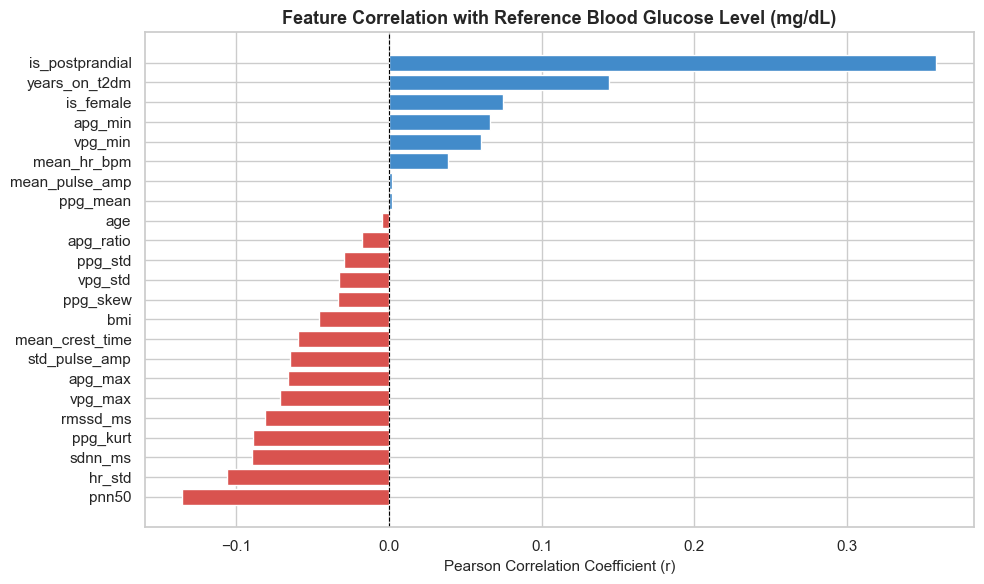

,Pearson (r),Spearman (rho)
is_postprandial,0.358480,0.416405
years_on_t2dm,0.144443,0.217337
is_female,0.074915,0.112653
apg_min,0.066000,-0.069039
vpg_min,0.060290,-0.166687
mean_hr_bpm,0.039012,-0.046429
mean_pulse_amp,0.001899,0.152728
ppg_mean,0.001855,-0.120374
age,-0.004314,-0.043151
apg_ratio,-0.017519,0.043600


In [11]:
corr_matrix = df_features.drop(columns=['participant_id']).corr(method='pearson')
bgl_corr = corr_matrix['bgl_mgdl'].drop('bgl_mgdl').sort_values()

# Plot Top Pearson Correlations with BGL
plt.figure(figsize=(10, 6))
colors = ['#d9534f' if x < 0 else '#428bca' for x in bgl_corr.values]
bars = plt.barh(bgl_corr.index, bgl_corr.values, color=colors)
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Feature Correlation with Reference Blood Glucose Level (mg/dL)', fontsize=13, fontweight='bold')
plt.xlabel('Pearson Correlation Coefficient (r)', fontsize=11)
plt.tight_layout()
plt.show()

# Display sorted correlations table
corr_table = pd.DataFrame({
    'Pearson (r)': bgl_corr,
    'Spearman (rho)': df_features.drop(columns=['participant_id']).corr(method='spearman')['bgl_mgdl'].drop('bgl_mgdl')
}).loc[bgl_corr.index[::-1]]

corr_table

In [15]:
# X = df_features.drop(columns=['bgl_mgdl', 'participant_id'])

sorted_corrs = corr_matrix['bgl_mgdl'].drop('bgl_mgdl').abs().sort_values(ascending=False)
top_5_features = sorted_corrs.head(5).index.tolist()


X = df_features[top_5_features].copy()
print(f"Selected Features: {X.columns}")
y = df_features['bgl_mgdl']
groups = df_features['participant_id']

# Subject-level splitting prevents identical physiological signatures from appearing in both train and test sets
gkf = GroupKFold(n_splits=5)

models = {
    "Ridge Regression": Pipeline([('scaler', StandardScaler()), ('reg', Ridge(alpha=10.0))]),
    "Random Forest": RandomForestRegressor(n_estimators=120, max_depth=5, min_samples_split=4, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=80, learning_rate=0.04, max_depth=3, random_state=42)
}

results = []
for name, model in models.items():
    scoring = {
        'mae': 'neg_mean_absolute_error',
        'rmse': 'neg_root_mean_squared_error',
        'r2': 'r2'
    }
    cv_scores = cross_validate(model, X, y, groups=groups, cv=gkf, scoring=scoring)
    
    results.append({
        "Model": name,
        "MAE (mg/dL)": -np.mean(cv_scores['test_mae']),
        "RMSE (mg/dL)": -np.mean(cv_scores['test_rmse']),
        "R² Score": np.mean(cv_scores['test_r2'])
    })

eval_df = pd.DataFrame(results).set_index("Model")
display(eval_df.round(3))

Selected Features: Index(['is_postprandial', 'years_on_t2dm', 'pnn50', 'hr_std', 'sdnn_ms'], dtype='object')


,MAE (mg/dL),RMSE (mg/dL),R² Score
Model,,,
Ridge Regression,40.774,55.899,-0.014
Random Forest,41.351,55.009,0.049
Gradient Boosting,45.015,59.664,-0.147
